In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

np.random.seed(42)

# Create labeled headline dataset
headlines = [
    # Security threats
    ("Militant group launches coordinated attack on military base", "Security Threat"),
    ("Suicide bomber kills dozens in crowded marketplace", "Security Threat"),
    ("Armed rebels seize control of border crossing", "Security Threat"),
    ("Terrorist cell dismantled by security forces", "Security Threat"),
    ("Missile strike destroys critical infrastructure", "Security Threat"),
    ("Gunmen attack police headquarters in capital city", "Security Threat"),
    ("Explosive device detonates near government building", "Security Threat"),
    ("Troops ambushed during patrol in conflict zone", "Security Threat"),
    ("Sniper kills senior military commander", "Security Threat"),
    ("Weapons cache discovered near civilian area", "Security Threat"),
    ("Armed group takes hostages in embassy attack", "Security Threat"),
    ("Drone strike eliminates high value target", "Security Threat"),
    ("Security forces repel insurgent offensive", "Security Threat"),
    ("Bomb disposal unit neutralizes threat in city center", "Security Threat"),
    ("Military convoy ambushed on highway", "Security Threat"),

    # Political instability
    ("Mass protests erupt following disputed election results", "Political Instability"),
    ("Prime minister resigns amid corruption scandal", "Political Instability"),
    ("Military coup topples elected government overnight", "Political Instability"),
    ("Opposition leader arrested on treason charges", "Political Instability"),
    ("Riots break out in capital after fuel price hike", "Political Instability"),
    ("Parliament dissolved as political crisis deepens", "Political Instability"),
    ("President declares state of emergency", "Political Instability"),
    ("Thousands march demanding government resignation", "Political Instability"),
    ("Election results contested amid fraud allegations", "Political Instability"),
    ("General strike paralyses economy for third day", "Political Instability"),
    ("Cabinet collapses after coalition partner withdraws", "Political Instability"),
    ("Protesters storm parliament building", "Political Instability"),
    ("Martial law declared in three provinces", "Political Instability"),
    ("Vice president flees country amid crisis", "Political Instability"),
    ("Constitutional court suspends election results", "Political Instability"),

    # Diplomatic
    ("Foreign ministers sign historic ceasefire agreement", "Diplomatic"),
    ("Nations agree on framework for nuclear disarmament", "Diplomatic"),
    ("Ambassador expelled following espionage accusations", "Diplomatic"),
    ("Peace talks resume after three year hiatus", "Diplomatic"),
    ("Trade delegation arrives for bilateral negotiations", "Diplomatic"),
    ("Countries normalize relations after decades of hostility", "Diplomatic"),
    ("UN security council votes on sanctions resolution", "Diplomatic"),
    ("NATO allies pledge increased defense spending", "Diplomatic"),
    ("Summit produces joint declaration on climate security", "Diplomatic"),
    ("Prisoner exchange completed under diplomatic agreement", "Diplomatic"),
    ("Foreign minister meets counterpart for crisis talks", "Diplomatic"),
    ("Treaty ratified by all member states", "Diplomatic"),
    ("Diplomatic mission evacuated from conflict zone", "Diplomatic"),
    ("Mediators announce breakthrough in peace process", "Diplomatic"),
    ("Bilateral agreement signed on border demarcation", "Diplomatic"),

    # Economic
    ("Central bank raises interest rates to combat inflation", "Economic"),
    ("Oil prices surge following supply disruption", "Economic"),
    ("Currency collapses amid financial crisis", "Economic"),
    ("Trade deficit widens as exports decline sharply", "Economic"),
    ("IMF approves emergency bailout package", "Economic"),
    ("Stock market crashes on recession fears", "Economic"),
    ("Energy company announces major offshore discovery", "Economic"),
    ("Sanctions bite as economy contracts for third quarter", "Economic"),
    ("Foreign investment reaches record high", "Economic"),
    ("Supply chain disruptions hit manufacturing sector", "Economic"),
    ("Unemployment rate hits decade high", "Economic"),
    ("Budget deficit balloons amid rising military spending", "Economic"),
    ("Commodity prices fall on weak demand outlook", "Economic"),
    ("Banking sector stress test reveals vulnerabilities", "Economic"),
    ("Economic growth slows amid global uncertainty", "Economic"),
]

df = pd.DataFrame(headlines, columns=['headline', 'category'])

print(f"Dataset shape: {df.shape}")
print("\nCategory distribution:")
print(df['category'].value_counts())
display(df.head(8))

Dataset shape: (60, 2)

Category distribution:
category
Security Threat          15
Political Instability    15
Diplomatic               15
Economic                 15
Name: count, dtype: int64


,headline,category
0,Militant group launches coordinated attack on ...,Security Threat
1,Suicide bomber kills dozens in crowded marketp...,Security Threat
2,Armed rebels seize control of border crossing,Security Threat
3,Terrorist cell dismantled by security forces,Security Threat
4,Missile strike destroys critical infrastructure,Security Threat
5,Gunmen attack police headquarters in capital city,Security Threat
6,Explosive device detonates near government bui...,Security Threat
7,Troops ambushed during patrol in conflict zone,Security Threat


In [ ]:
# CountVectorizer implements Bag of Words
# It builds a vocabulary of all unique words
# then represents each headline as a vector of word counts

vectorizer = CountVectorizer(
    stop_words='english',  # remove common words like "the", "a", "in"
    min_df=2               # only include words that appear at least twice
)

# Fit and transform the headlines
X = vectorizer.fit_transform(df['headline'])
y = df['category']

# See the vocabulary
vocabulary = vectorizer.get_feature_names_out()
print(f"Total unique words in vocabulary: {len(vocabulary)}")
print(f"\nSample words from vocabulary:")
print(vocabulary[:30])

# Convert to dataframe so we can see the matrix
word_matrix = pd.DataFrame(
    X.toarray(),
    columns=vocabulary
)

print(f"\nWord matrix shape: {word_matrix.shape}")
print("\nSample of word matrix (first 5 headlines, first 10 words):")
display(word_matrix.iloc[:5, :10])

Total unique words in vocabulary: 42

Sample words from vocabulary:
['agreement' 'ambushed' 'amid' 'armed' 'attack' 'bilateral' 'border'
 'building' 'capital' 'city' 'collapses' 'conflict' 'crisis' 'deficit'
 'diplomatic' 'economy' 'election' 'emergency' 'following' 'forces'
 'foreign' 'government' 'group' 'high' 'kills' 'military' 'minister'
 'near' 'parliament' 'peace']

Word matrix shape: (60, 42)

Sample of word matrix (first 5 headlines, first 10 words):


,agreement,ambushed,amid,armed,attack,bilateral,border,building,capital,city
0,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0


In [ ]:
# TF-IDF instead of raw counts
tfidf = TfidfVectorizer(
    stop_words='english',
    min_df=2
)

X_tfidf = tfidf.fit_transform(df['headline'])

# Compare a single headline representation
# Bag of Words vs TF-IDF
headline_idx = 0
bow_values = word_matrix.iloc[headline_idx]
tfidf_values = pd.Series(
    X_tfidf.toarray()[headline_idx],
    index=tfidf.get_feature_names_out()
)

print(f"Headline: '{df['headline'].iloc[headline_idx]}'")
print(f"\nTop 5 words by Bag of Words score:")
print(bow_values[bow_values > 0].sort_values(ascending=False).head())
print(f"\nTop 5 words by TF-IDF score:")
print(tfidf_values[tfidf_values > 0].sort_values(ascending=False).head())

Headline: 'Militant group launches coordinated attack on military base'

Top 5 words by Bag of Words score:
attack      1
group       1
military    1
Name: 0, dtype: int64

Top 5 words by TF-IDF score:
group       0.626707
attack      0.581772
military    0.518439
dtype: float64


In [ ]:
# A Pipeline chains steps together so we can classify
# raw text directly without manually vectorizing first
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', min_df=1)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df['headline'], df['category'],
    test_size=0.2,
    random_state=42,
    stratify=df['category']  # ensure each category is represented in test set
)

print(f"Training headlines: {len(X_train)}")
print(f"Test headlines: {len(X_test)}")
print(f"\nTest set category distribution:")
print(y_test.value_counts())

# Train the pipeline
pipeline.fit(X_train, y_train)

# Evaluate
predictions = pipeline.predict(X_test)
print(f"\nModel accuracy: {accuracy_score(y_test, predictions):.1%}")
print("\nDetailed breakdown:")
print(classification_report(y_test, predictions))

Training headlines: 48
Test headlines: 12

Test set category distribution:
category
Political Instability    3
Economic                 3
Diplomatic               3
Security Threat          3
Name: count, dtype: int64

Model accuracy: 25.0%

Detailed breakdown:
                       precision    recall  f1-score   support

           Diplomatic       0.25      0.33      0.29         3
             Economic       0.00      0.00      0.00         3
Political Instability       0.00      0.00      0.00         3
      Security Threat       0.40      0.67      0.50         3

             accuracy                           0.25        12
            macro avg       0.16      0.25      0.20        12
         weighted avg       0.16      0.25      0.20        12



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(classification_report(y_test, predictions, zero_division=0))

                       precision    recall  f1-score   support

           Diplomatic       0.25      0.33      0.29         3
             Economic       0.00      0.00      0.00         3
Political Instability       0.00      0.00      0.00         3
      Security Threat       0.40      0.67      0.50         3

             accuracy                           0.25        12
            macro avg       0.16      0.25      0.20        12
         weighted avg       0.16      0.25      0.20        12



In [ ]:
headlines_expanded = [
    # Security Threat
    ("Militant group launches coordinated attack on military base", "Security Threat"),
    ("Suicide bomber kills dozens in crowded marketplace", "Security Threat"),
    ("Armed rebels seize control of border crossing", "Security Threat"),
    ("Terrorist cell dismantled by security forces", "Security Threat"),
    ("Missile strike destroys critical infrastructure", "Security Threat"),
    ("Gunmen attack police headquarters in capital city", "Security Threat"),
    ("Explosive device detonates near government building", "Security Threat"),
    ("Troops ambushed during patrol in conflict zone", "Security Threat"),
    ("Sniper kills senior military commander", "Security Threat"),
    ("Weapons cache discovered near civilian area", "Security Threat"),
    ("Armed group takes hostages in embassy attack", "Security Threat"),
    ("Drone strike eliminates high value target", "Security Threat"),
    ("Security forces repel insurgent offensive", "Security Threat"),
    ("Bomb disposal unit neutralizes threat in city center", "Security Threat"),
    ("Military convoy ambushed on highway", "Security Threat"),
    ("Insurgents detonate car bomb outside police station", "Security Threat"),
    ("Special forces raid weapons smuggling network", "Security Threat"),
    ("Rocket attack kills civilians in residential area", "Security Threat"),
    ("Extremist group claims responsibility for massacre", "Security Threat"),
    ("Naval vessel attacked in disputed waters", "Security Threat"),
    ("Suicide vest bomber targets crowded train station", "Security Threat"),
    ("Militants execute captured soldiers on video", "Security Threat"),
    ("Mortar fire hits UN peacekeeping compound", "Security Threat"),
    ("Armed faction seizes government radio station", "Security Threat"),
    ("Assassination attempt on senior official foiled", "Security Threat"),
    ("Hostage rescue operation launched by special forces", "Security Threat"),
    ("Chemical agent detected near military installation", "Security Threat"),
    ("Guerrilla fighters ambush supply convoy", "Security Threat"),
    ("Explosive laden vehicle rams security checkpoint", "Security Threat"),
    ("Sniper fire disrupts evacuation of wounded civilians", "Security Threat"),
    ("Armed group destroys power grid in coordinated attack", "Security Threat"),
    ("Terrorist suspects arrested at international airport", "Security Threat"),
    ("Military helicopter shot down over conflict zone", "Security Threat"),
    ("Bomb maker arrested with materials for large device", "Security Threat"),
    ("Extremists torch village forcing mass displacement", "Security Threat"),
    ("Cyberattack disables air traffic control systems", "Security Threat"),
    ("Armed militia blocks humanitarian aid convoy", "Security Threat"),
    ("Intelligence services foil plot against parliament", "Security Threat"),
    ("Landmine kills farmers in demilitarized zone", "Security Threat"),
    ("Militant sniper targets journalists covering conflict", "Security Threat"),
    ("Armed group kidnaps foreign aid workers", "Security Threat"),
    ("Security forces discover tunnel network under border", "Security Threat"),
    ("Explosive device found on passenger train", "Security Threat"),
    ("Armed faction attacks rival group in refugee camp", "Security Threat"),
    ("Suicide attack kills worshippers at mosque", "Security Threat"),
    ("Military base hit by coordinated mortar barrage", "Security Threat"),
    ("Gunmen storm hotel killing foreign tourists", "Security Threat"),
    ("Weapons depot explodes in suspected sabotage", "Security Threat"),
    ("Armed group seizes oil facility taking workers hostage", "Security Threat"),
    ("Security services intercept planned attack on metro", "Security Threat"),

    # Political Instability
    ("Mass protests erupt following disputed election results", "Political Instability"),
    ("Prime minister resigns amid corruption scandal", "Political Instability"),
    ("Military coup topples elected government overnight", "Political Instability"),
    ("Opposition leader arrested on treason charges", "Political Instability"),
    ("Riots break out in capital after fuel price hike", "Political Instability"),
    ("Parliament dissolved as political crisis deepens", "Political Instability"),
    ("President declares state of emergency", "Political Instability"),
    ("Thousands march demanding government resignation", "Political Instability"),
    ("Election results contested amid fraud allegations", "Political Instability"),
    ("General strike paralyses economy for third day", "Political Instability"),
    ("Cabinet collapses after coalition partner withdraws", "Political Instability"),
    ("Protesters storm parliament building", "Political Instability"),
    ("Martial law declared in three provinces", "Political Instability"),
    ("Vice president flees country amid crisis", "Political Instability"),
    ("Constitutional court suspends election results", "Political Instability"),
    ("Ruling party loses majority in snap election", "Political Instability"),
    ("Angry crowds burn ruling party headquarters", "Political Instability"),
    ("Senior minister defects to opposition amid scandal", "Political Instability"),
    ("Police fire tear gas at demonstrators outside palace", "Political Instability"),
    ("Governor impeached following mass protests", "Political Instability"),
    ("Military surrounds parliament amid political standoff", "Political Instability"),
    ("Thousands detained in crackdown on dissent", "Political Instability"),
    ("President accused of electoral fraud by opposition", "Political Instability"),
    ("Anti government demonstrations spread to rural areas", "Political Instability"),
    ("Curfew imposed after clashes between rival factions", "Political Instability"),
    ("Whistleblower exposes corruption at highest levels", "Political Instability"),
    ("Supreme court ruling triggers constitutional crisis", "Political Instability"),
    ("Hunger strike by political prisoners enters third week", "Political Instability"),
    ("Journalists arrested for reporting on government abuses", "Political Instability"),
    ("Ruling coalition fractures over austerity measures", "Political Instability"),
    ("Ethnic tensions boil over in disputed region", "Political Instability"),
    ("Election commission resigns over interference claims", "Political Instability"),
    ("Mass exodus of government officials amid scandal", "Political Instability"),
    ("Student protests shut down universities nationwide", "Political Instability"),
    ("Security services accused of torturing detainees", "Political Instability"),
    ("President extends term limits sparking outrage", "Political Instability"),
    ("Opposition boycotts election calling process illegitimate", "Political Instability"),
    ("Nationwide blackout sparks conspiracy theories and unrest", "Political Instability"),
    ("Leaked documents reveal government surveillance program", "Political Instability"),
    ("Regional governor declares independence from central government", "Political Instability"),
    ("Protests turn violent as police use live ammunition", "Political Instability"),
    ("Prime minister survived no confidence vote by slim margin", "Political Instability"),
    ("Allegations of vote rigging plunge country into turmoil", "Political Instability"),
    ("Army chief warns of intervention if crisis continues", "Political Instability"),
    ("Minister of interior resigns over police brutality scandal", "Political Instability"),
    ("Referendum on independence declared illegal by government", "Political Instability"),
    ("Dissident politician granted asylum abroad", "Political Instability"),
    ("Snap election called after government loses confidence vote", "Political Instability"),
    ("Violent clashes between protesters and riot police reported", "Political Instability"),
    ("Ruling party accused of suppressing opposition candidates", "Political Instability"),

    # Diplomatic
    ("Foreign ministers sign historic ceasefire agreement", "Diplomatic"),
    ("Nations agree on framework for nuclear disarmament", "Diplomatic"),
    ("Ambassador expelled following espionage accusations", "Diplomatic"),
    ("Peace talks resume after three year hiatus", "Diplomatic"),
    ("Trade delegation arrives for bilateral negotiations", "Diplomatic"),
    ("Countries normalize relations after decades of hostility", "Diplomatic"),
    ("UN security council votes on sanctions resolution", "Diplomatic"),
    ("NATO allies pledge increased defense spending", "Diplomatic"),
    ("Summit produces joint declaration on climate security", "Diplomatic"),
    ("Prisoner exchange completed under diplomatic agreement", "Diplomatic"),
    ("Foreign minister meets counterpart for crisis talks", "Diplomatic"),
    ("Treaty ratified by all member states", "Diplomatic"),
    ("Diplomatic mission evacuated from conflict zone", "Diplomatic"),
    ("Mediators announce breakthrough in peace process", "Diplomatic"),
    ("Bilateral agreement signed on border demarcation", "Diplomatic"),
    ("Security council imposes arms embargo on regime", "Diplomatic"),
    ("Envoy appointed to lead ceasefire negotiations", "Diplomatic"),
    ("Nations agree to prisoner swap after months of talks", "Diplomatic"),
    ("Foreign aid package approved for conflict affected region", "Diplomatic"),
    ("Multilateral summit addresses regional security concerns", "Diplomatic"),
    ("Diplomatic ties restored after ten year freeze", "Diplomatic"),
    ("International observers deployed to monitor elections", "Diplomatic"),
    ("Sanctions lifted following compliance with nuclear deal", "Diplomatic"),
    ("Emergency UN session called to address crisis", "Diplomatic"),
    ("Joint military exercises signal strengthened alliance", "Diplomatic"),
    ("Humanitarian corridor established through diplomatic effort", "Diplomatic"),
    ("Foreign minister summoned to explain military actions", "Diplomatic"),
    ("Regional bloc imposes travel ban on junta leaders", "Diplomatic"),
    ("Ceasefire monitored by international peacekeeping force", "Diplomatic"),
    ("Heads of state meet for emergency security summit", "Diplomatic"),
    ("Diplomatic back channel established to defuse tensions", "Diplomatic"),
    ("UN envoy shuttles between capitals seeking compromise", "Diplomatic"),
    ("Countries agree to joint border patrol mechanism", "Diplomatic"),
    ("International tribunal rules on disputed territory", "Diplomatic"),
    ("Foreign ministry issues formal protest over incursion", "Diplomatic"),
    ("Alliance members invoke mutual defense clause", "Diplomatic"),
    ("Warring parties agree to exchange bodies of fallen soldiers", "Diplomatic"),
    ("International community condemns use of chemical weapons", "Diplomatic"),
    ("Mediator proposes five point peace plan to rival factions", "Diplomatic"),
    ("Diplomatic pressure mounts on regime over human rights", "Diplomatic"),
    ("Foreign minister tours region to build coalition support", "Diplomatic"),
    ("Nations sign agreement on refugee burden sharing", "Diplomatic"),
    ("Multilateral force authorized to protect civilian population", "Diplomatic"),
    ("Security guarantees offered as part of peace framework", "Diplomatic"),
    ("Countries agree to establish hotline to prevent incidents", "Diplomatic"),
    ("UN resolution calls for immediate withdrawal of forces", "Diplomatic"),
    ("Diplomatic solution sought as military options considered", "Diplomatic"),
    ("Foreign envoys meet rebel leaders in secret negotiations", "Diplomatic"),
    ("Regional powers broker power sharing agreement", "Diplomatic"),
    ("International sanctions regime tightened on nuclear program", "Diplomatic"),

    # Economic
    ("Central bank raises interest rates to combat inflation", "Economic"),
    ("Oil prices surge following supply disruption", "Economic"),
    ("Currency collapses amid financial crisis", "Economic"),
    ("Trade deficit widens as exports decline sharply", "Economic"),
    ("IMF approves emergency bailout package", "Economic"),
    ("Stock market crashes on recession fears", "Economic"),
    ("Energy company announces major offshore discovery", "Economic"),
    ("Sanctions bite as economy contracts for third quarter", "Economic"),
    ("Foreign investment reaches record high", "Economic"),
    ("Supply chain disruptions hit manufacturing sector", "Economic"),
    ("Unemployment rate hits decade high", "Economic"),
    ("Budget deficit balloons amid rising military spending", "Economic"),
    ("Commodity prices fall on weak demand outlook", "Economic"),
    ("Banking sector stress test reveals vulnerabilities", "Economic"),
    ("Economic growth slows amid global uncertainty", "Economic"),
    ("Government announces austerity measures to cut deficit", "Economic"),
    ("Inflation hits thirty year high straining household budgets", "Economic"),
    ("Foreign debt reaches unsustainable levels warns economist", "Economic"),
    ("Energy crisis drives up production costs across industries", "Economic"),
    ("Trade war escalates as tariffs imposed on key goods", "Economic"),
    ("Financial markets volatile amid geopolitical tensions", "Economic"),
    ("Bank run forces emergency liquidity injection", "Economic"),
    ("Export ban on grain triggers global food price spike", "Economic"),
    ("GDP contracts for second consecutive quarter", "Economic"),
    ("Sovereign wealth fund depleted to cover budget shortfall", "Economic"),
    ("Major employer announces mass layoffs citing falling demand", "Economic"),
    ("Credit rating downgraded amid fiscal concerns", "Economic"),
    ("Energy subsidy cuts spark public anger and protests", "Economic"),
    ("Foreign currency reserves fall to critically low levels", "Economic"),
    ("Debt restructuring deal reached with international creditors", "Economic"),
    ("Rising fuel costs ground national airline fleet", "Economic"),
    ("Wheat shortage looms as harvest fails for second year", "Economic"),
    ("Technology sector investment collapses amid uncertainty", "Economic"),
    ("Pension fund crisis threatens retirement security", "Economic"),
    ("Black market exchange rate doubles official rate", "Economic"),
    ("Port strike disrupts trade flows for second week", "Economic"),
    ("Government defaults on international bond payment", "Economic"),
    ("Oil revenue decline forces cuts to public services", "Economic"),
    ("Manufacturing output falls to lowest level in decade", "Economic"),
    ("Remittances decline as diaspora faces economic hardship", "Economic"),
    ("Food inflation forces millions into poverty", "Economic"),
    ("Capital flight accelerates as investors lose confidence", "Economic"),
    ("Central bank depletes reserves defending currency peg", "Economic"),
    ("Economic sanctions reduce oil exports by half", "Economic"),
    ("Housing market collapse triggers broader financial crisis", "Economic"),
    ("Gas supply cuts force industrial rationing", "Economic"),
    ("Corruption investigation freezes billions in state assets", "Economic"),
    ("Import restrictions cause shortages of basic goods", "Economic"),
    ("Tourism collapse devastates coastal economies", "Economic"),
    ("Microfinance sector collapse leaves millions in debt", "Economic"),
]

df2 = pd.DataFrame(headlines_expanded, columns=['headline', 'category'])

print(f"Dataset shape: {df2.shape}")
print("\nCategory distribution:")
print(df2['category'].value_counts())

Dataset shape: (200, 2)

Category distribution:
category
Security Threat          50
Political Instability    50
Diplomatic               50
Economic                 50
Name: count, dtype: int64


In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    df2['headline'], df2['category'],
    test_size=0.2,
    random_state=42,
    stratify=df2['category']
)

print(f"Training headlines: {len(X2_train)}")
print(f"Test headlines: {len(X2_test)}")

pipeline2 = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', min_df=1)),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

pipeline2.fit(X2_train, y2_train)
predictions2 = pipeline2.predict(X2_test)

print(f"\nModel accuracy: {accuracy_score(y2_test, predictions2):.1%}")
print("\nDetailed breakdown:")
print(classification_report(y2_test, predictions2, zero_division=0))

Training headlines: 160
Test headlines: 40

Model accuracy: 67.5%

Detailed breakdown:
                       precision    recall  f1-score   support

           Diplomatic       0.70      0.70      0.70        10
             Economic       0.53      0.90      0.67        10
Political Instability       0.89      0.80      0.84        10
      Security Threat       0.75      0.30      0.43        10

             accuracy                           0.68        40
            macro avg       0.72      0.68      0.66        40
         weighted avg       0.72      0.68      0.66        40



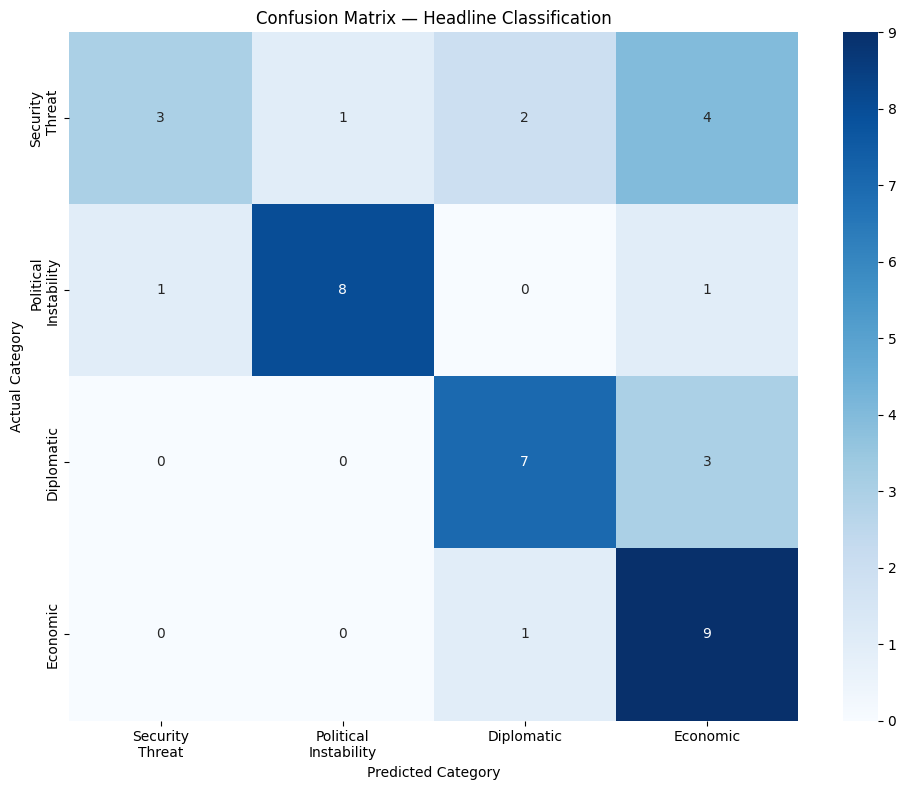

In [ ]:
cm = confusion_matrix(y2_test, predictions2,
                      labels=['Security Threat', 'Political Instability',
                              'Diplomatic', 'Economic'])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Security\nThreat', 'Political\nInstability',
                         'Diplomatic', 'Economic'],
            yticklabels=['Security\nThreat', 'Political\nInstability',
                         'Diplomatic', 'Economic'])

plt.title('Confusion Matrix — Headline Classification')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.tight_layout()
plt.show()

In [ ]:
def classify_headline(headline):
    prediction = pipeline2.predict([headline])[0]
    probabilities = pipeline2.predict_proba([headline])[0]
    categories = pipeline2.classes_

    prob_df = pd.DataFrame({
        'Category': categories,
        'Confidence': probabilities
    }).sort_values('Confidence', ascending=False)

    print(f"Headline: '{headline}'")
    print(f"Classification: {prediction}")
    print(f"\nConfidence breakdown:")
    for _, row in prob_df.iterrows():
        bar = '█' * int(row['Confidence'] * 30)
        print(f"{row['Category']:<25} {bar} {row['Confidence']:.1%}")
    print("---")

# Try these headlines
classify_headline("Bombs falling over Bagdhad as oil prices rise")
classify_headline("Interest rates held steady amid inflation concerns")
classify_headline("Opposition leader calls for national dialogue")
classify_headline("Bomb squad called to suspicious package near embassy")

Headline: 'Bombs falling over Bagdhad as oil prices rise'
Classification: Economic

Confidence breakdown:
Economic                  █████████████ 46.0%
Political Instability     ██████ 22.5%
Security Threat           █████ 17.0%
Diplomatic                ████ 14.5%
---
Headline: 'Interest rates held steady amid inflation concerns'
Classification: Economic

Confidence breakdown:
Economic                  ██████████████████ 62.0%
Political Instability     ████████ 29.0%
Diplomatic                █ 5.5%
Security Threat           █ 3.5%
---
Headline: 'Opposition leader calls for national dialogue'
Classification: Political Instability

Confidence breakdown:
Political Instability     ███████████████████ 65.5%
Economic                  ████ 13.5%
Diplomatic                ███ 12.0%
Security Threat           ██ 9.0%
---
Headline: 'Bomb squad called to suspicious package near embassy'
Classification: Security Threat

Confidence breakdown:
Security Threat           ████████████████ 54.5%
Econom